# Week 2-3 Listing Raw Data EDA Questions

This notebook answers the Week 2-3 EDA questions using raw monthly CRMLS listing files.

Because this is listing data, the sold-specific question about homes sold above or below list price is adapted to compare `ListPrice` against `OriginalListPrice`.

## 1. Import Packages And Set Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "data" / "reports" / "week2_3_listing_raw_questions"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

START_MONTH = "202401"
END_MONTH = "202605"

## 2. Load All Raw Listing Files

In [2]:
def month_range(start_month, end_month):
    year = int(start_month[:4])
    month = int(start_month[4:])
    end_year = int(end_month[:4])
    end_month_num = int(end_month[4:])

    while (year, month) <= (end_year, end_month_num):
        yield f"{year}{month:02d}"
        month += 1
        if month == 13:
            month = 1
            year += 1


def select_listing_file(month):
    filled_file = RAW_DIR / f"CRMLSListing{month}_filled.csv"
    regular_file = RAW_DIR / f"CRMLSListing{month}.csv"

    if filled_file.exists():
        return filled_file
    if regular_file.exists():
        return regular_file
    return None


frames = []
missing_months = []

for month in month_range(START_MONTH, END_MONTH):
    file_path = select_listing_file(month)
    if file_path is None:
        missing_months.append(month)
        continue

    df = pd.read_csv(file_path, low_memory=False)

    # If future listing *_filled files exist, follow the same rule as sold files:
    # drop the two helper columns at the end before combining.
    if file_path.stem.endswith("_filled"):
        df = df.iloc[:, :-2]

    df["SourceMonth"] = month
    df["SourceFile"] = file_path.name
    frames.append(df)

listings_all = pd.concat(frames, ignore_index=True, sort=False)

print(f"Rows loaded: {len(listings_all):,}")
print(f"Columns loaded: {listings_all.shape[1]:,}")
print(f"Missing months: {missing_months if missing_months else 'none'}")
listings_all.head()

Rows loaded: 929,505
Columns loaded: 86
Missing months: none


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,SourceMonth,SourceFile
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61,202401,CRMLSListing202401.csv
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN,202401,CRMLSListing202401.csv
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704,202401,CRMLSListing202401.csv
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,3.0,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades,202401,CRMLSListing202401.csv
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road,202401,CRMLSListing202401.csv


## 3. What Is The Residential Vs. Other Property Type Share?

In [3]:
property_type_summary = (
    listings_all["PropertyType"]
    .fillna("Missing")
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .reset_index()
)
property_type_summary.columns = ["PropertyType", "row_count"]
property_type_summary["share_pct"] = (
    property_type_summary["row_count"] / len(listings_all) * 100
).round(2)

property_type_summary

,PropertyType,row_count,share_pct
0,Residential,591409,63.63
1,ResidentialLease,192291,20.69
2,Land,60596,6.52
3,ResidentialIncome,34534,3.72
4,ManufacturedInPark,26619,2.86
5,CommercialSale,12711,1.37
6,CommercialLease,8366,0.90
7,BusinessOpportunity,2979,0.32


In [4]:
listings_residential = listings_all[
    listings_all["PropertyType"].astype(str).str.strip().eq("Residential")
].copy()

residential_share = len(listings_residential) / len(listings_all) * 100
other_share = 100 - residential_share

print(f"Residential rows: {len(listings_residential):,}")
print(f"Residential share: {residential_share:.2f}%")
print(f"Other property type share: {other_share:.2f}%")

Residential rows: 591,409
Residential share: 63.63%
Other property type share: 36.37%


## 4. What Are The Median And Average Listing Prices?

For listing data, `ListPrice` is the main price field. `ClosePrice` is also summarized when available, but it may be less complete in listing extracts.

In [5]:
list_price = pd.to_numeric(listings_residential["ListPrice"], errors="coerce")
original_list_price = pd.to_numeric(listings_residential["OriginalListPrice"], errors="coerce")
close_price = pd.to_numeric(listings_residential.get("ClosePrice"), errors="coerce")

price_summary = pd.DataFrame([
    {"metric": "average_list_price", "value": list_price.mean()},
    {"metric": "median_list_price", "value": list_price.median()},
    {"metric": "average_original_list_price", "value": original_list_price.mean()},
    {"metric": "median_original_list_price", "value": original_list_price.median()},
    {"metric": "average_close_price_if_available", "value": close_price.mean()},
    {"metric": "median_close_price_if_available", "value": close_price.median()},
    {"metric": "non_missing_list_price_rows", "value": list_price.count()},
    {"metric": "non_missing_close_price_rows", "value": close_price.count()},
])

price_summary

,metric,value
0,average_list_price,1.318434e+06
1,median_list_price,8.488880e+05
2,average_original_list_price,1.402465e+06
3,median_original_list_price,8.490000e+05
4,average_close_price_if_available,1.209515e+06
5,median_close_price_if_available,8.580000e+05
6,non_missing_list_price_rows,5.914090e+05
7,non_missing_close_price_rows,1.459730e+05


## 5. What Does The Days On Market Distribution Look Like?

In [6]:
days_on_market = pd.to_numeric(listings_residential["DaysOnMarket"], errors="coerce")

dom_summary = days_on_market.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
dom_summary

count    591409.000000
mean         18.691056
std          25.894727
min         -58.000000
1%            0.000000
5%            0.000000
25%           5.000000
50%          11.000000
75%          22.000000
95%          68.000000
99%         135.000000
max        1063.000000
Name: DaysOnMarket, dtype: float64

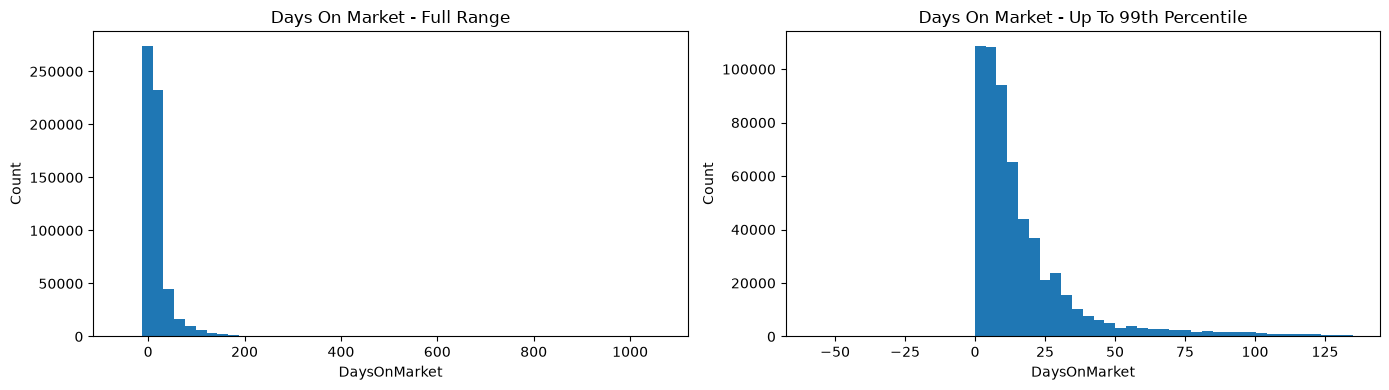

In [7]:
dom_clean = days_on_market.dropna()
dom_p99 = dom_clean.quantile(0.99)
dom_zoomed = dom_clean[dom_clean <= dom_p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dom_clean, bins=50)
axes[0].set_title("Days On Market - Full Range")
axes[0].set_xlabel("DaysOnMarket")
axes[0].set_ylabel("Count")

axes[1].hist(dom_zoomed, bins=50)
axes[1].set_title("Days On Market - Up To 99th Percentile")
axes[1].set_xlabel("DaysOnMarket")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "days_on_market_distribution.png")
plt.show()

## 6. What Percentage Of Listings Are Above Vs. Below Original List Price?

This is the listing-data version of the sold above/below list price question. It compares current `ListPrice` against `OriginalListPrice`.

In [8]:
valid_price_pairs = pd.DataFrame({
    "ListPrice": list_price,
    "OriginalListPrice": original_list_price,
}).dropna()

below_original_count = int((valid_price_pairs["ListPrice"] < valid_price_pairs["OriginalListPrice"]).sum())
above_original_count = int((valid_price_pairs["ListPrice"] > valid_price_pairs["OriginalListPrice"]).sum())
unchanged_count = int((valid_price_pairs["ListPrice"] == valid_price_pairs["OriginalListPrice"]).sum())
total_pairs = len(valid_price_pairs)

list_to_original_summary = pd.DataFrame([
    {"category": "current_list_price_below_original", "row_count": below_original_count, "share_pct": below_original_count / total_pairs * 100},
    {"category": "current_list_price_above_original", "row_count": above_original_count, "share_pct": above_original_count / total_pairs * 100},
    {"category": "current_list_price_unchanged", "row_count": unchanged_count, "share_pct": unchanged_count / total_pairs * 100},
])

list_to_original_summary["share_pct"] = list_to_original_summary["share_pct"].round(2)
list_to_original_summary

,category,row_count,share_pct
0,current_list_price_below_original,96076,16.27
1,current_list_price_above_original,16863,2.86
2,current_list_price_unchanged,477628,80.88


## 7. Are There Any Apparent Date Consistency Issues?

In [ ]:
listing_date = pd.to_datetime(listings_residential["ListingContractDate"], errors="coerce")
contract_status_date = pd.to_datetime(listings_residential["ContractStatusChangeDate"], errors="coerce")
purchase_date = pd.to_datetime(listings_residential.get("PurchaseContractDate"), errors="coerce")
close_date = pd.to_datetime(listings_residential.get("CloseDate"), errors="coerce")

date_issue_summary = pd.DataFrame([
    {
        "issue": "ContractStatusChangeDate before ListingContractDate",
        "row_count": int((contract_status_date < listing_date).sum()),
    },
    {
        "issue": "PurchaseContractDate before ListingContractDate",
        "row_count": int((purchase_date < listing_date).sum()),
    },
    {
        "issue": "CloseDate before ListingContractDate",
        "row_count": int((close_date < listing_date).sum()),
    },
    {
        "issue": "Missing ListingContractDate",
        "row_count": int(listing_date.isna().sum()),
    },
    {
        "issue": "Missing ContractStatusChangeDate",
        "row_count": int(contract_status_date.isna().sum()),
    },
    {
        "issue": "Missing PurchaseContractDate",
        "row_count": int(purchase_date.isna().sum()),
    },
    {
        "issue": "Missing CloseDate",
        "row_count": int(close_date.isna().sum()),
    },
])

date_issue_summary

# a small amount of listing has data inconsistnecies, should be flagged for data quality review.

,issue,row_count
0,ContractStatusChangeDate before ListingContrac...,138
1,PurchaseContractDate before ListingContractDate,292
2,CloseDate before ListingContractDate,79
3,Missing ListingContractDate,0
4,Missing ContractStatusChangeDate,6908
5,Missing PurchaseContractDate,309388
6,Missing CloseDate,422534


## 8. Which Counties Have The Highest Median Listing Prices?

In [10]:
county_median_prices = (
    listings_residential.assign(ListPriceNumeric=list_price)
    .dropna(subset=["CountyOrParish", "ListPriceNumeric"])
    .groupby("CountyOrParish")
    .agg(
        listing_count=("ListPriceNumeric", "size"),
        median_list_price=("ListPriceNumeric", "median"),
        average_list_price=("ListPriceNumeric", "mean"),
    )
    .reset_index()
    .sort_values("median_list_price", ascending=False)
)

county_median_prices.head(10)

,CountyOrParish,listing_count,median_list_price,average_list_price
45,San Mateo,10897,1648990.0,2.421566e+06
47,Santa Clara,28820,1499000.0,1.916938e+06
22,Marin,248,1260000.0,1.679983e+06
48,Santa Cruz,5017,1250000.0,1.535044e+06
31,Orange,56528,1220000.0,1.794163e+06
42,San Francisco,1654,1098000.0,1.342199e+06
0,Alameda,28354,998000.0,1.180863e+06
28,Monterey,5740,995000.0,1.726917e+06
20,Los Angeles,150243,950000.0,1.713560e+06
41,San Diego,74106,915000.0,1.315074e+06


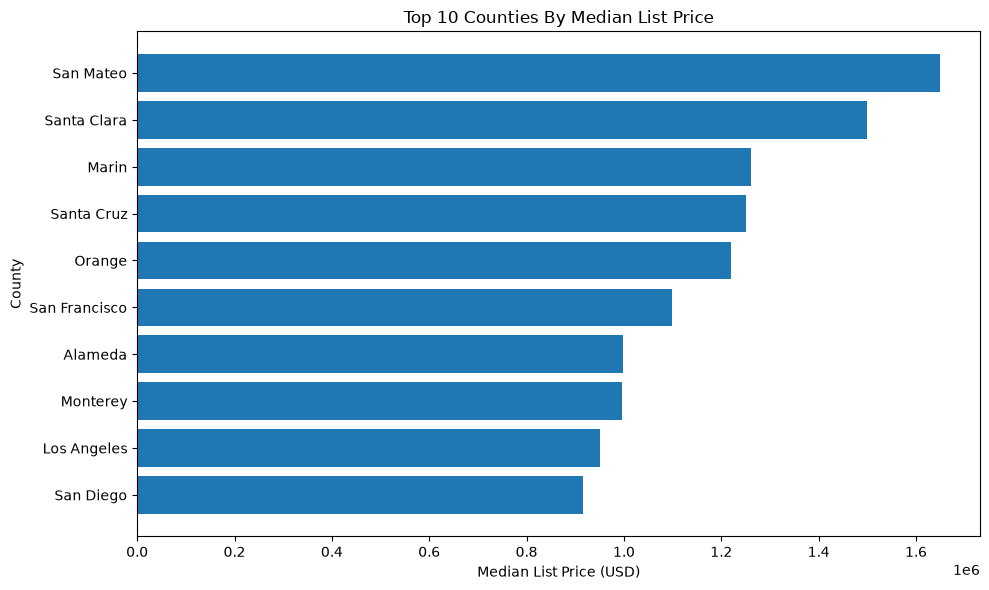

In [11]:
top_counties = county_median_prices.head(10).sort_values("median_list_price")

plt.figure(figsize=(10, 6))
plt.barh(top_counties["CountyOrParish"], top_counties["median_list_price"])
plt.title("Top 10 Counties By Median List Price")
plt.xlabel("Median List Price (USD)")
plt.ylabel("County")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_counties_median_list_price.png")
plt.show()

## 9. Save Question Outputs

In [12]:
property_type_summary.to_csv(REPORT_DIR / "property_type_share.csv", index=False)
price_summary.to_csv(REPORT_DIR / "price_summary.csv", index=False)
dom_summary.to_frame(name="DaysOnMarket").to_csv(REPORT_DIR / "days_on_market_summary.csv")
list_to_original_summary.to_csv(REPORT_DIR / "list_to_original_price_summary.csv", index=False)
date_issue_summary.to_csv(REPORT_DIR / "date_issue_summary.csv", index=False)
county_median_prices.to_csv(REPORT_DIR / "county_median_list_prices.csv", index=False)

print("Saved reports to:", REPORT_DIR)
print("Saved figures to:", FIGURE_DIR)

Saved reports to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/week2_3_listing_raw_questions
Saved figures to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/week2_3_listing_raw_questions/figures
